# AMJax : RSS Benchmark

Compares AMJax (JAX multigrid) against PyAMG and SciPy CG on 2D Poisson problems.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vboussange/AMJax/blob/main/benchmarks/rss.ipynb)

In [1]:
import timeit

import numpy as np
import jax
import jax.numpy as jnp
import pyamg
from pyamg.relaxation.smoothing import change_smoothers
from scipy.sparse.linalg import cg

from amjax import AMJAXSolver
from benchmarks.params import (
    TOL as tol,
    MAXITER_VCYCLE as maxiter_vcycle,
    MAXITER_SOLV as maxiter_solv,
    GRID_SIZE as grid_size,
    VMAP_K,
    SOLVER,
)
from benchmarks.plots import (
    plot_runtime,
    plot_residual,
    plot_float_precision,
    save_results,
    load_results,
)

jax.config.update("jax_enable_x64", True)
np.random.seed(42)

print(f"JAX backend : {jax.devices()[0].platform}")
print(f"Grid sizes  : {grid_size}")
print(f"Batch size  : {VMAP_K}")


JAX backend : cpu
Grid sizes  : [50, 100]
Batch size  : 64


In [2]:
SOLVERS = {
    "smoothed_aggregation": pyamg.smoothed_aggregation_solver,
    "rootnode": pyamg.rootnode_solver,
    "pairwise": pyamg.pairwise_solver,
    "ruge_stuben": pyamg.ruge_stuben_solver,
    "air": pyamg.air_solver,
}

## Solver definitions

In [3]:
@jax.jit
def amjax_solve(ml, b):
    x = ml.solve(b, tol=tol, maxiter=maxiter_vcycle)
    error = jnp.linalg.norm(b - ml.levels[0].A @ x) / jnp.linalg.norm(b)
    return x, error

@jax.jit
def amjax_pcg_solve(ml, b):
    M = ml.aspreconditioner()
    x, _ = jax.scipy.sparse.linalg.cg(ml.levels[0].A, b, M=M, tol=tol, maxiter=maxiter_solv)
    error = jnp.linalg.norm(b - ml.levels[0].A @ x) / jnp.linalg.norm(b)
    return x, error

def pyamg_solve(ml, b):
    x = ml.solve(b, tol=tol, maxiter=maxiter_vcycle, cycle='V')
    error = np.linalg.norm(b - ml.levels[0].A @ x) / np.linalg.norm(b)
    return x, error

def pyamg_pcg_solve(ml, b):
    M = ml.aspreconditioner()
    x, _ = cg(ml.levels[0].A, b, M=M, rtol=tol, maxiter=maxiter_solv)
    error = np.linalg.norm(b - ml.levels[0].A @ x) / np.linalg.norm(b)
    return x, error

def cg_solve(A, b):
    x, _ = cg(A, b, rtol=tol, maxiter=maxiter_solv)
    error = np.linalg.norm(b - A @ x) / np.linalg.norm(b)
    return x, error

In [4]:
# Batch solvers

def pyamg_solve_batch(ml, B):
    results = [pyamg_solve(ml, B[i]) for i in range(len(B))]
    return np.array([x for x, _ in results]), float(np.mean([e for _, e in results]))

def pyamg_pcg_solve_batch(ml, B):
    results = [pyamg_pcg_solve(ml, B[i]) for i in range(len(B))]
    return np.array([x for x, _ in results]), float(np.mean([e for _, e in results]))

def cg_solve_batch(A, B):
    results = [cg_solve(A, B[i]) for i in range(len(B))]
    return np.array([x for x, _ in results]), float(np.mean([e for _, e in results]))

def amjax_solve_batch(ml, B):
    results = [amjax_solve(ml, B[i]) for i in range(len(B))]
    return np.array([x for x, _ in results]), float(np.mean([e for _, e in results]))

def amjax_pcg_solve_batch(ml, B):
    results = [amjax_pcg_solve(ml, B[i]) for i in range(len(B))]
    return np.array([x for x, _ in results]), float(np.mean([e for _, e in results]))

def amjax_vmap_solve_batch(ml, B):
    results = jax.vmap(lambda b: amjax_solve(ml, b))(B)
    return results[0], float(jnp.mean(results[1]))

def amjax_pcg_vmap_solve_batch(ml, B):
    results = jax.vmap(lambda b: amjax_pcg_solve(ml, b))(B)
    return results[0], float(jnp.mean(results[1]))

In [5]:
def benchmark(method, func, is_jax=False):
    if is_jax:
        jax.block_until_ready(func())

    times = timeit.repeat(func, number=1, repeat=10)
    _, error = func()
    print(f"{method}/ time: {min(times):.4f}s/ residual: {float(error):.2e}")
    return min(times), error

def cast_solver(ml, dtype):
    for lvl in ml.levels:
        lvl.A = lvl.A.astype(dtype)
        lvl.Dinv = lvl.Dinv.astype(dtype)
        if lvl.P is not None: lvl.P = lvl.P.astype(dtype)
        if lvl.R is not None: lvl.R = lvl.R.astype(dtype)
    return ml

## Benchmark

In [ ]:
time_pyamg, time_amjax, time_amjax_pcg, time_cg, time_pyamg_pcg, time_amjax_vmap, time_amjax_pcg_vmap = [], [], [], [], [], [], []
res_pyamg, res_amjax, res_amjax_pcg, res_cg, res_pyamg_pcg, res_amjax_vmap, res_amjax_pcg_vmap = [], [], [], [], [], [], []
res_amjax_f32, res_amjax_pcg_f32 = [], []

for n in grid_size:
    print(f"Grid size: {n}x{n}")
    A = pyamg.gallery.poisson((n, n), format="csr")
    B = np.random.rand(VMAP_K, A.shape[0])
    B_jax = jnp.array(B)
    B_f32 = jnp.array(B, dtype=jnp.float32)

    ml = SOLVERS[SOLVER](A, coarse_solver="jacobi")
    change_smoothers(ml, presmoother="jacobi", postsmoother="jacobi")
    ml_jax = AMJAXSolver.from_pyamg(
        ml,
        presmoother=("jacobi", {"iterations": 1, "withrho": True}),
        postsmoother=("jacobi", {"iterations": 1, "withrho": True}),
    )
    ml_f32 = cast_solver(AMJAXSolver.from_pyamg(
        ml,
        presmoother=("jacobi", {"iterations": 1, "withrho": True}),
        postsmoother=("jacobi", {"iterations": 1, "withrho": True}),
    ), jnp.float32)

    time, error = benchmark(f"PyAMG-{SOLVER}", lambda: pyamg_solve_batch(ml, B), is_jax=False)
    time_pyamg.append(time); res_pyamg.append(error)

    # time, error = benchmark(f"PyAMG-{SOLVER}-PCG", lambda: pyamg_pcg_solve_batch(ml, B), is_jax=False)
    # time_pyamg_pcg.append(time); res_pyamg_pcg.append(error)

    # time, error = benchmark("CG", lambda: cg_solve_batch(A, B), is_jax=False)
    # time_cg.append(time); res_cg.append(error)

    time, error = benchmark(f"AMJAX-{SOLVER}", lambda: amjax_solve_batch(ml_jax, B_jax), is_jax=True)
    time_amjax.append(time); res_amjax.append(error)

    # time, error = benchmark(f"AMJAX-{SOLVER}-PCG", lambda: amjax_pcg_solve_batch(ml_jax, B_jax), is_jax=True)
    # time_amjax_pcg.append(time); res_amjax_pcg.append(error)

    time, error = benchmark(f"AMJAX-{SOLVER} vmap", lambda: amjax_vmap_solve_batch(ml_jax, B_jax), is_jax=True)
    time_amjax_vmap.append(time); res_amjax_vmap.append(error)

    # time, error = benchmark(f"AMJAX-{SOLVER}-PCG vmap", lambda: amjax_pcg_vmap_solve_batch(ml_jax, B_jax), is_jax=True)
    # time_amjax_pcg_vmap.append(time); res_amjax_pcg_vmap.append(error)

    _, error = benchmark(f"AMJAX-{SOLVER} f32", lambda: amjax_vmap_solve_batch(ml_f32, B_f32), is_jax=True)
    res_amjax_f32.append(error)

    # _, error = benchmark(f"AMJAX-{SOLVER}-PCG f32", lambda: amjax_pcg_solve_batch(ml_f32, B_f32), is_jax=True)
    res_amjax_pcg_f32.append(error)


Grid size: 50x50
PyAMG-smoothed_aggregation/ time: 0.4444s/ residual: 7.84e-11
PyAMG-smoothed_aggregation-PCG/ time: 0.2188s/ residual: 6.04e-11
AMJAX-smoothed_aggregation/ time: 0.5190s/ residual: 7.99e-11
AMJAX-smoothed_aggregation-PCG/ time: 0.2109s/ residual: 3.20e-11
AMJAX-smoothed_aggregation vmap/ time: 0.0946s/ residual: 7.99e-11
AMJAX-smoothed_aggregation-PCG vmap/ time: 0.0417s/ residual: 3.20e-11
AMJAX-smoothed_aggregation f32/ time: 0.1318s/ residual: 1.98e-05
AMJAX-smoothed_aggregation-PCG f32/ time: 0.2055s/ residual: 3.59e-05
Grid size: 100x100
PyAMG-smoothed_aggregation/ time: 1.2073s/ residual: 8.54e-11
PyAMG-smoothed_aggregation-PCG/ time: 0.5447s/ residual: 8.54e-11
AMJAX-smoothed_aggregation/ time: 2.7342s/ residual: 8.93e-11
AMJAX-smoothed_aggregation-PCG/ time: 0.9545s/ residual: 5.56e-11
AMJAX-smoothed_aggregation vmap/ time: 0.5199s/ residual: 8.93e-11
AMJAX-smoothed_aggregation-PCG vmap/ time: 0.2060s/ residual: 5.56e-11
AMJAX-smoothed_aggregation f32/ time: 0.

In [ ]:
save_results({
    "solver":              SOLVER,
    "grid_size":           grid_size,
    "vmap_k":              VMAP_K,
    "time_pyamg":          time_pyamg,
    # "time_pyamg_pcg":      time_pyamg_pcg,
    # "time_cg":             time_cg,
    "time_amjax":          time_amjax,
    # "time_amjax_pcg":      time_amjax_pcg,
    "time_amjax_vmap":     time_amjax_vmap,
    # "time_amjax_pcg_vmap": time_amjax_pcg_vmap,
    "res_pyamg":           res_pyamg,
    # "res_pyamg_pcg":       res_pyamg_pcg,
    # "res_cg":              res_cg,
    "res_amjax":           res_amjax,
    # "res_amjax_pcg":       res_amjax_pcg,
    "res_amjax_vmap":      res_amjax_vmap,
    # "res_amjax_pcg_vmap":  res_amjax_pcg_vmap,
    "res_amjax_f32":       res_amjax_f32,
    # "res_amjax_pcg_f32":   res_amjax_pcg_f32,
}, f"solver_benchmark_{SOLVER}.json")


Results saved → /Users/fannymissillier/Desktop/AMJax/results/solver_benchmark_smoothed_aggregation.json


## Results

In [ ]:
W = max(len(f"AMJAX-{SOLVER}-PCG vmap"), len(f"PyAMG-{SOLVER}-PCG")) + 2
print(f"\n{'=' * 62}")
print(f"  Benchmark Results — {SOLVER} — batch K={VMAP_K}")
print(f"{'=' * 62}")

solvers_res = [
    (f"PyAMG-{SOLVER}", time_pyamg, res_pyamg),
    # (f"PyAMG-{SOLVER}-PCG", time_pyamg_pcg, res_pyamg_pcg),
    # ("CG", time_cg, res_cg),
    (f"AMJAX-{SOLVER}", time_amjax, res_amjax),
    # (f"AMJAX-{SOLVER}-PCG", time_amjax_pcg, res_amjax_pcg),
    (f"AMJAX-{SOLVER} vmap", time_amjax_vmap, res_amjax_vmap),
    # (f"AMJAX-{SOLVER}-PCG vmap", time_amjax_pcg_vmap, res_amjax_pcg_vmap),
]

for i, n in enumerate(grid_size):
    print(f"\n  Grid size : {n} x {n}\n")
    print(f"  {'Solver':<{W}} {'Time (s)':>10}  {'Residual':>12}")
    print(f"  {'-' * (W + 26)}")
    for name, times, residuals in solvers_res:
        print(f"  {name:<{W}} {times[i]:>10.4f}  {residuals[i]:>12.2e}")

print(f"{'=' * 62}")


  Benchmark Results — smoothed_aggregation — batch K=64

  Grid size : 50 x 50

  Solver                                  Time (s)      Residual
  ---------------------------------------------------------------
  PyAMG-smoothed_aggregation                0.4444      7.84e-11
  PyAMG-smoothed_aggregation-PCG            0.2188      6.04e-11
  AMJAX-smoothed_aggregation                0.5190      7.99e-11
  AMJAX-smoothed_aggregation-PCG            0.2109      3.20e-11
  AMJAX-smoothed_aggregation vmap           0.0946      7.99e-11
  AMJAX-smoothed_aggregation-PCG vmap       0.0417      3.20e-11

  Grid size : 100 x 100

  Solver                                  Time (s)      Residual
  ---------------------------------------------------------------
  PyAMG-smoothed_aggregation                1.2073      8.54e-11
  PyAMG-smoothed_aggregation-PCG            0.5447      8.54e-11
  AMJAX-smoothed_aggregation                2.7342      8.93e-11
  AMJAX-smoothed_aggregation-PCG            0.

## Plots

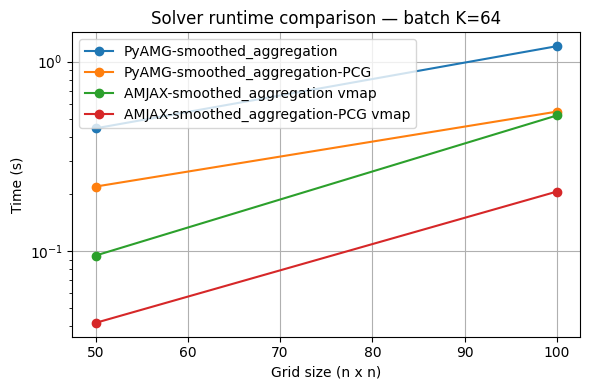

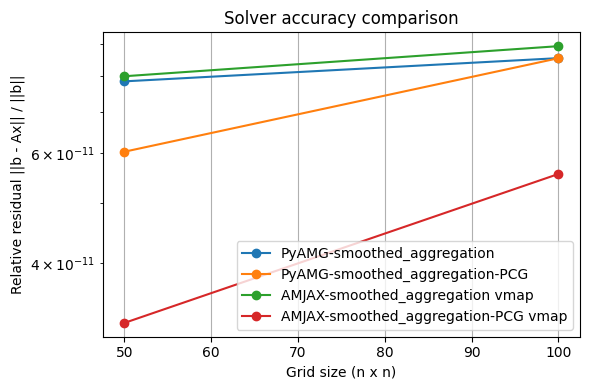

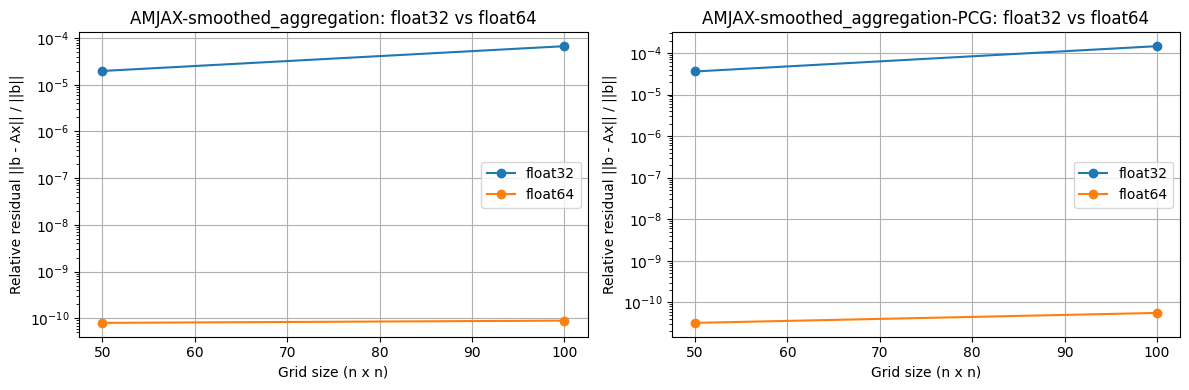

In [ ]:
plot_runtime(grid_size, [
    (f"PyAMG-{SOLVER}", time_pyamg),
    # (f"PyAMG-{SOLVER}-PCG", time_pyamg_pcg),
    (f"AMJAX-{SOLVER} vmap", time_amjax_vmap),
    # (f"AMJAX-{SOLVER}-PCG vmap", time_amjax_pcg_vmap),
    # ("CG", time_cg),
], VMAP_K, show=True)

plot_residual(grid_size, [
    (f"PyAMG-{SOLVER}", res_pyamg),
    # (f"PyAMG-{SOLVER}-PCG", res_pyamg_pcg),
    (f"AMJAX-{SOLVER} vmap", res_amjax_vmap),
    #(f"AMJAX-{SOLVER}-PCG vmap", res_amjax_pcg_vmap),
    # ("CG", res_cg),
], show=True)


plot_float_precision(grid_size, [
    (f"AMJAX-{SOLVER}", res_amjax_f32, res_amjax),
    # (f"AMJAX-{SOLVER}-PCG", res_amjax_pcg_f32, res_amjax_pcg),
], show=True)
